In [41]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

from GKP_simulator import GKPStabilizationSimulator as gkp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# General Parameters

In [42]:
# --- Hilbert-space truncation ---
N = 50  # Fock space dimension

# stabalization parameters
n_stab_cycles = 20       # number of rounds
delta_fb = 0.174 # approximate feedback shift size for sharp trim stabilization, can be adjusted. 0.2
eps_trim = 0.279  # dimensionless, tune this for envelope 0.18

# --- initial state ---
# can start in thermal state too, stabalization seems to work for many different thermal photon numbers
rho_init = qt.thermal_dm(N, 1)
# rho_init = qt.fock_dm(N, 3)  
gkp_state = gkp(N=N, n_stabalization_cycles=n_stab_cycles, rho_initial=rho_init, eps_trim=eps_trim, delta_fb=delta_fb)

# Create mixed state in code manifold

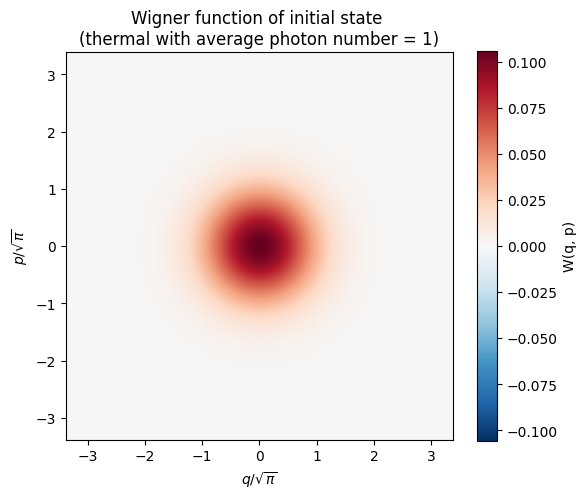

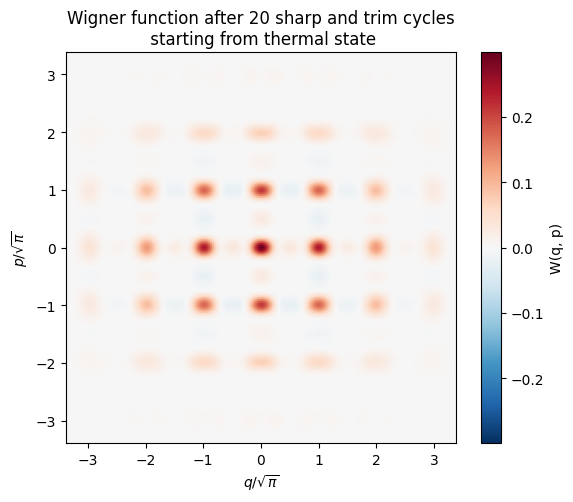

In [43]:
gkp_state.rho_logical_mixed = gkp_state.run_stabalization() # perform st stabalization

gkp_state.plot_wigner(rho_init, title_str='Wigner function of initial state \n(thermal with average photon number = 1)') # plot initial state wigner function
gkp_state.plot_wigner(gkp_state.rho_logical_mixed, title_str=f'Wigner function after {n_stab_cycles} sharp and trim cycles\n starting from thermal state') # plot wigner function after stabilization

# Hereld pure logical state

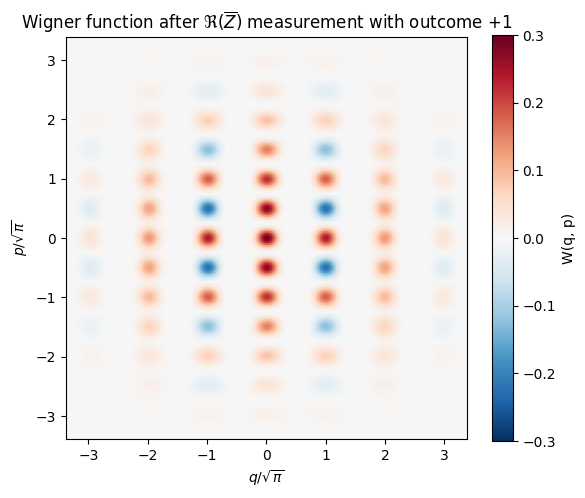

In [44]:
gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2) # measure from mixed logical state, get pure state. This is +Z eigenstate

gkp_state.plot_wigner(
    gkp_state.rho_logical_pure,
    title_str=r'Wigner function after $\Re(\overline{Z})$ measurement with outcome $+1$'
)

# Plot photon number distribution

<BarContainer object of 50 artists>

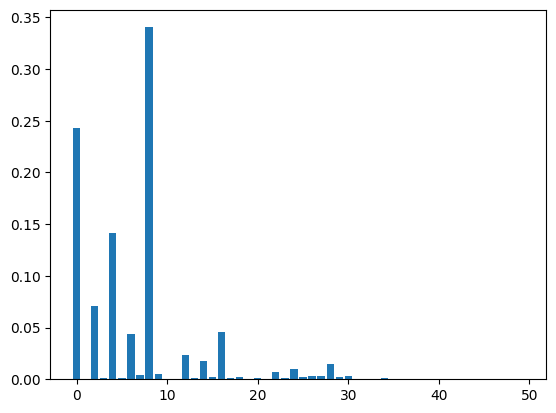

In [5]:
plt.bar(np.arange(0,N),gkp_state.rho_logical_pure.diag())

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/var/folders/h4/tktr_62d465dx1dq_x0czdz80000gn/T/ipykernel_47849/442864805.py:3: SyntaxWarning: invalid escape sequence '\D'
  gkp_state_plot.plot_wigner(rho_ideal_Z0, title_str=f'Wigner function of approximate +Z eigenstate with $\Delta = 0.25$')


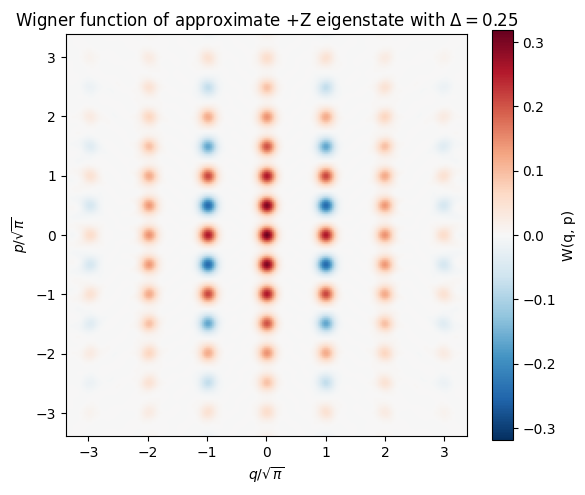

[2.36427479e-01 0.00000000e+00 7.56505520e-02 0.00000000e+00
 1.37049590e-01 0.00000000e+00 2.63113505e-02 0.00000000e+00
 3.27987530e-01 0.00000000e+00 6.53651321e-04 0.00000000e+00
 1.63749520e-02 0.00000000e+00 2.63149356e-02 0.00000000e+00
 6.62773856e-02 0.00000000e+00 6.62074106e-03 0.00000000e+00
 1.08069718e-03 0.00000000e+00 6.74639134e-03 0.00000000e+00
 1.84534923e-02 0.00000000e+00 1.78881990e-05 0.00000000e+00
 3.88383717e-02 0.00000000e+00 1.16894945e-03 0.00000000e+00
 7.19536927e-04 0.00000000e+00 1.08019056e-03 0.00000000e+00
 1.16822299e-03 0.00000000e+00 1.41057173e-04 0.00000000e+00
 5.95872451e-03 0.00000000e+00 1.11035503e-03 0.00000000e+00
 5.10257206e-05 0.00000000e+00 6.43674636e-05 0.00000000e+00
 1.52859261e-04 0.00000000e+00 2.71400788e-04 0.00000000e+00
 7.59532997e-05 0.00000000e+00 7.35793700e-06 0.00000000e+00
 1.18718599e-03 0.00000000e+00 2.53673654e-06 0.00000000e+00
 2.53543927e-04 0.00000000e+00 1.16242393e-04 0.00000000e+00
 1.08672969e-04 0.000000

In [6]:
gkp_state_plot = gkp(N=200, n_stabalization_cycles=n_stab_cycles, rho_initial=rho_init, eps_trim=eps_trim, delta_fb=delta_fb)
rho_ideal_Z0 = gkp_state_plot.prep_envelope_Z0_logical_state(8, 0.25)
gkp_state_plot.plot_wigner(rho_ideal_Z0, title_str=f'Wigner function of approximate +Z eigenstate with $\Delta = 0.25$')

print(rho_ideal_Z0.diag())

# Calculate various properties

In [ ]:
print((gkp_state.conditional_displacement_kraus(gkp_state.a_lat*gkp_state.q_op/2,'X',1)*gkp_state.rho_logical_pure*gkp_state.conditional_displacement_kraus(gkp_state.a_lat*gkp_state.q_op/2,'X',1).dag()).tr()) # logical Z+  probability
print((gkp_state.rho_logical_pure*gkp_state.Z_logical).tr().real) # logical Z expectation value
print((gkp_state.rho_logical_mixed*gkp_state.S_x).tr().real) # stabalizer S_x expectation value of mixed state. 

rho_psharp = gkp_state.conditional_displacement_kraus(gkp_state.a_lat*gkp_state.p_op,'Y',1)*gkp_state.rho_logical_pure*gkp_state.conditional_displacement_kraus(gkp_state.a_lat*gkp_state.p_op,'Y',1).dag() # rho after p sharpening without feedback displacement

rho_psharp = rho_psharp/rho_psharp.tr() # normalize

print((rho_psharp*gkp_state.Z_logical).tr().real) # logical Z expectation value after p sharpening

print((gkp_state.rho_logical_mixed*gkp_state.Z_logical).tr().real)  # logical Z expectation value of mixed state. should be close to zero

# p sharpening round does X gate on logical qubit

0.9603133681093449
0.9206267362186902
0.7951618622471447
-0.9163331744646748
0.09374234342586255


# look at trim feedback displacement

x_max of P_q: -0.0012515644555693983
x_max of P_q * back_action: -0.1088861076345432
delta x: -0.10763454317897381


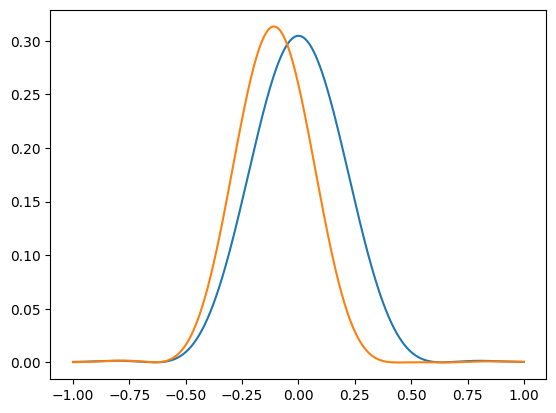

In [8]:
# zoomed in plot of q marginal and back-action for q sharpening measurement

gkp_state.xmax = 1        # for ploting wigner functions
gkp_state.npts = 800   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.rho_logical_pure)
back_action = np.cos((gkp_state.a_lat*xlist + np.pi/2)/2)**2

plt.plot(xlist,P_q)
plt.plot(xlist,1.7*P_q*back_action)

# indices of maxima
i1 = np.argmax(P_q)
i2 = np.argmax(P_q * back_action)

# corresponding x positions
x1 = xlist[i1]
x2 = xlist[i2]

# difference in x position between the two peaks
dx = x2 - x1

print("x_max of P_q:", x1)
print("x_max of P_q * back_action:", x2)
print("delta x:", dx)

# Logical pauli measurment backaction

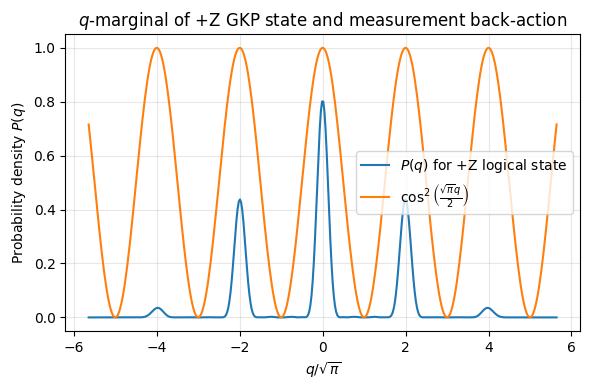

In [9]:
# measurement back-action for Z measurement

gkp_state.xmax = 10        # for ploting wigner functions
gkp_state.npts = 400   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.rho_logical_pure)
back_action = np.cos(gkp_state.a_lat*xlist/4)**2 # measure +Z eigenstate


plt.figure(figsize=(6, 4))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for +Z logical state'
)
plt.plot(
    xlist/np.sqrt(np.pi),
    back_action,
    label=r'$\cos^2\left(\frac{\sqrt{\pi}q}{2}\right)$'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'$q$-marginal of +Z GKP state and measurement back-action')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Demonstrate sharp

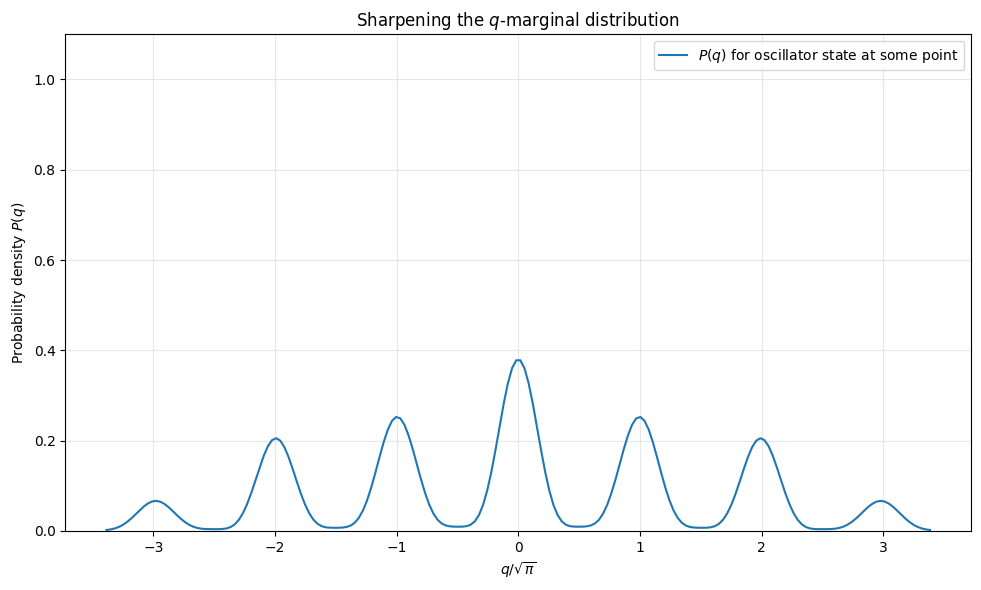

In [ ]:
# show sharp and trim on q marginal. Initial state is after 4 cycles of stabalization

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.a_lat*xlist + np.pi/2)/2)**2 # measure qubit to be in +y
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Initial $q$ probability distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

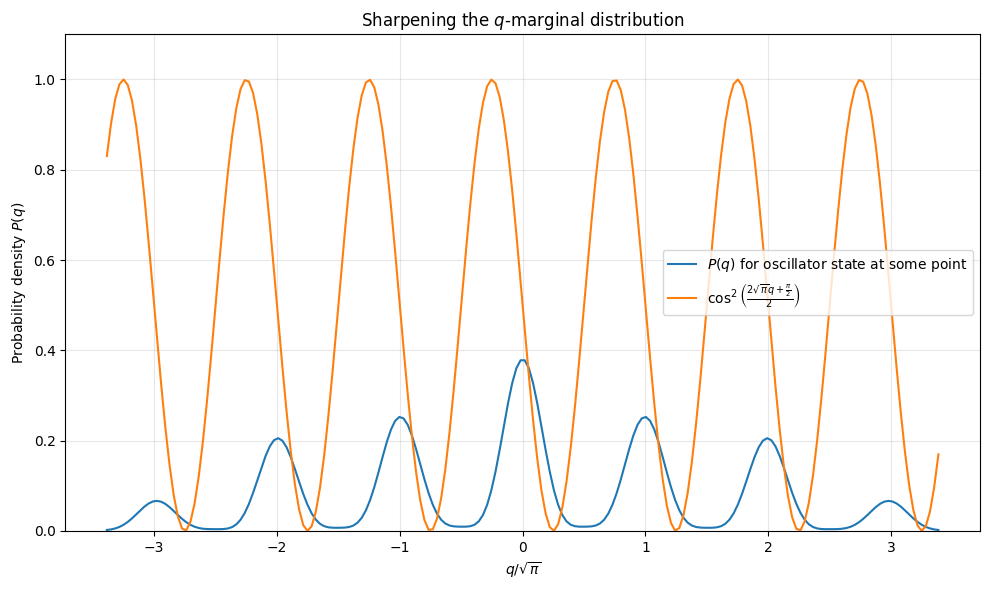

In [ ]:
# show sharp and trim on q marginal. Show sinusoid back-action

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.a_lat*xlist + np.pi/2)/2)**2 # measure qubit to be in +y
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)
plt.plot(
    xlist/np.sqrt(np.pi),
    back_action,
    label=r'$\cos^2\left(\frac{2\sqrt{\pi}q + \frac{\pi}{2}}{2}\right)$'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Initial $q$ probability distribution with measurement back-action')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

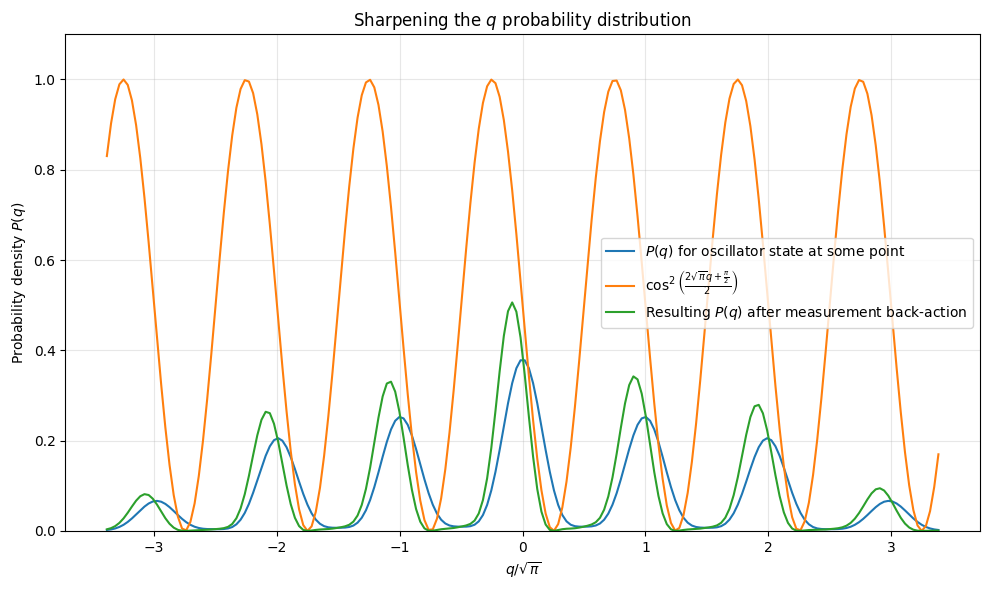

In [18]:
# show sharp and trim on q marginal, show resulting distribution after back-action

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.a_lat*xlist + np.pi/2)/2)**2 # measure qubit to be in +y
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)
plt.plot(
    xlist/np.sqrt(np.pi),
    back_action,
    label=r'$\cos^2\left(\frac{2\sqrt{\pi}q + \frac{\pi}{2}}{2}\right)$'
)

plt.plot(
    xlist/np.sqrt(np.pi),
    result,
    label=r'Resulting $P(q)$ after measurement back-action'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Sharpening the $q$ probability distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

# demonstrate trim

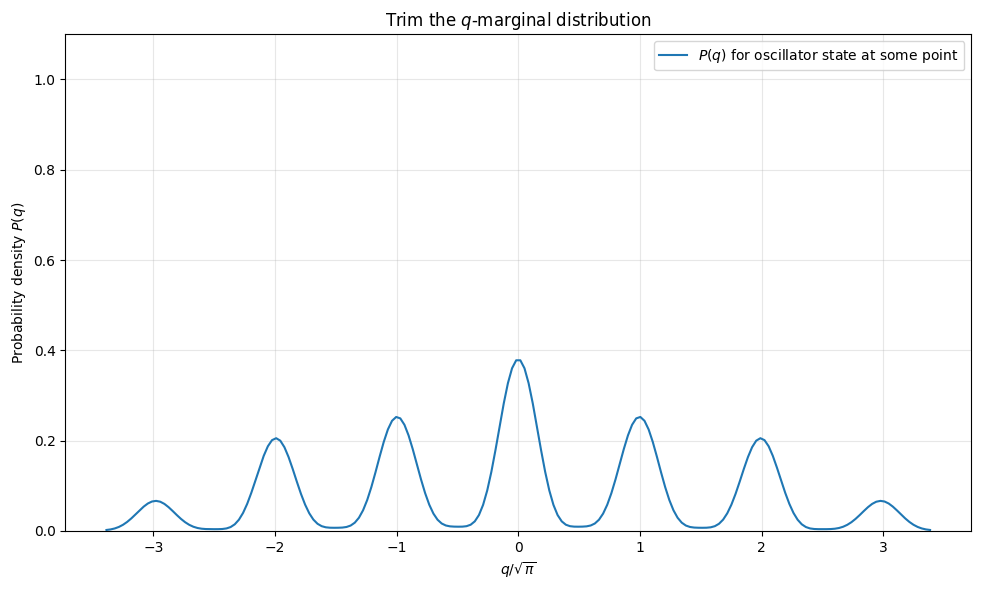

In [13]:
# trim operation, show initial state

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.eps_trim_default*xlist + np.pi/2)/2)**2
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Trim the $q$-marginal distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

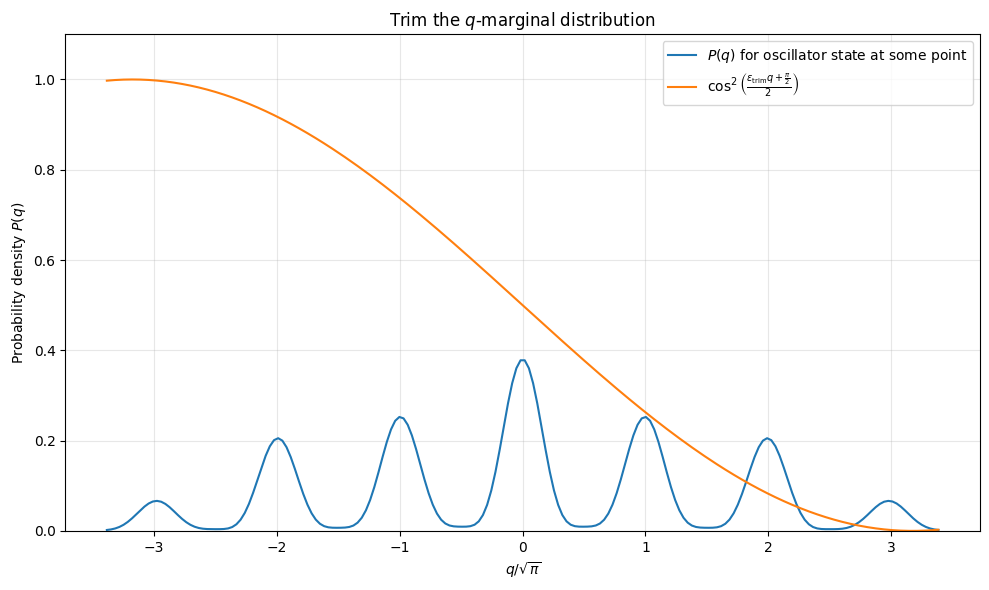

In [14]:
# trim operation, show initial state

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.eps_trim_default*xlist + np.pi/2)/2)**2
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)
plt.plot(
    xlist/np.sqrt(np.pi),
    back_action,
    label=r'$\cos^2\left(\frac{\epsilon_{\mathrm{trim}}q + \frac{\pi}{2}}{2}\right)$')

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Trim the $q$-marginal distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

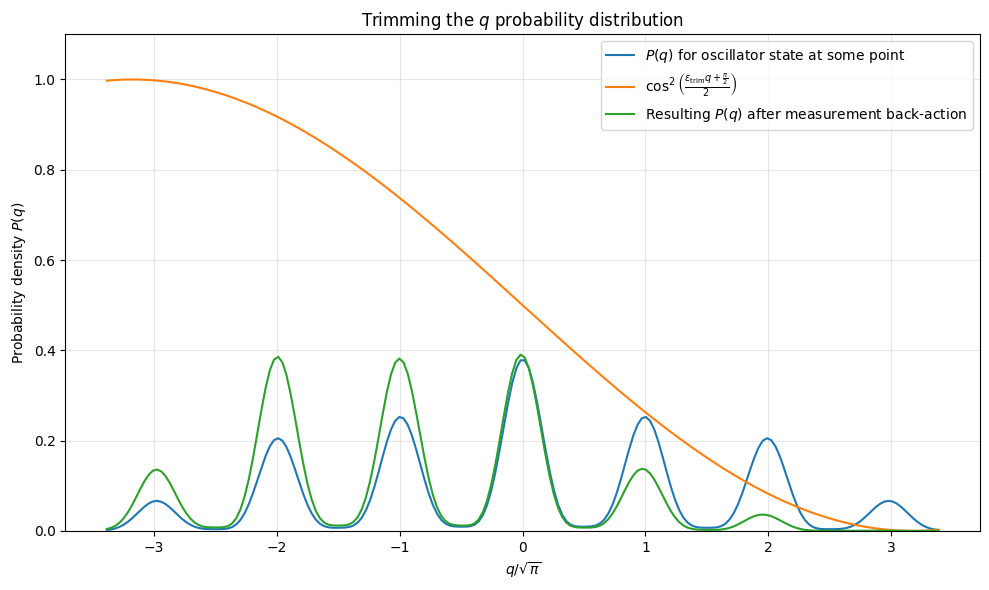

In [21]:
# trim operation, show initial state

gkp_state.xmax = 6        # for ploting wigner functions
gkp_state.npts = 200   

P_q, xlist = gkp_state.get_q_marginal(gkp_state.run_stabalization(n_cycles=4))
back_action = np.cos((gkp_state.eps_trim_default*xlist + np.pi/2)/2)**2
result = P_q * back_action / np.trapezoid(P_q * back_action, xlist)  # normalized result

plt.figure(figsize=(10, 6))

plt.plot(
    xlist/np.sqrt(np.pi),
    P_q,
    label=r'$P(q)$ for oscillator state at some point'
)
plt.plot(
    xlist/np.sqrt(np.pi),
    back_action,
    label=r'$\cos^2\left(\frac{\epsilon_{\mathrm{trim}}q + \frac{\pi}{2}}{2}\right)$')
plt.plot(
    xlist/np.sqrt(np.pi),
    result,
    label=r'Resulting $P(q)$ after measurement back-action'
)

plt.xlabel(r'$q / \sqrt{\pi}$')
plt.ylabel(r'Probability density $P(q)$')
plt.title(r'Trimming the $q$ probability distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0,1.1)
plt.show()

# Show p sharp and q trim basically apply logical X operation

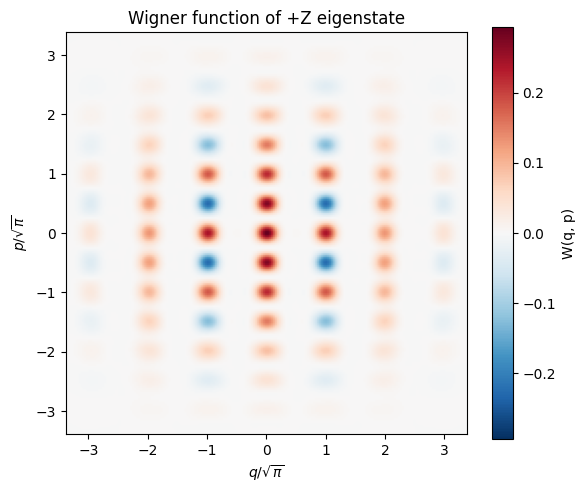

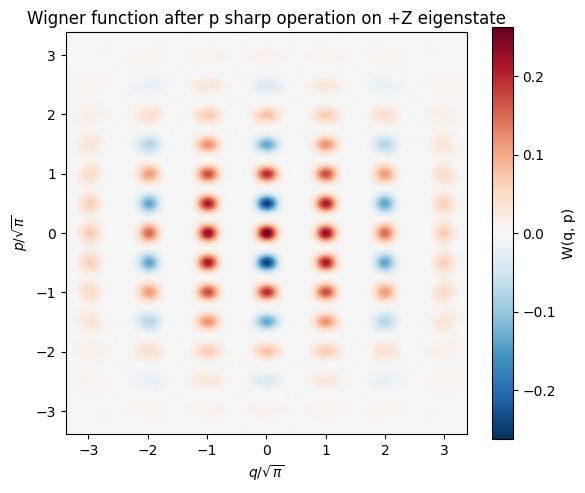

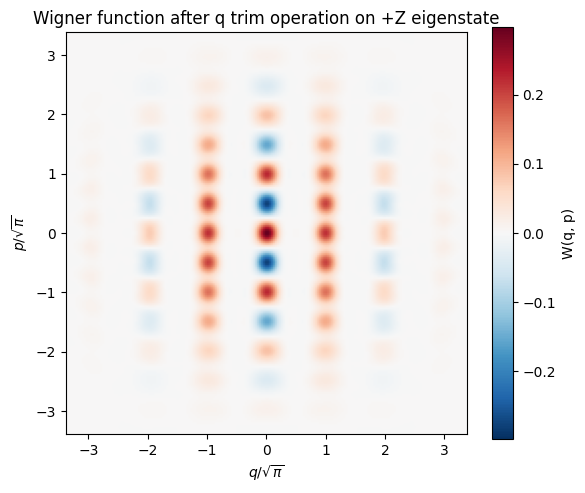

In [26]:
# zxxz are effective gates when doing sharp and trim which equals 1 so all good.
# test this with wigner tomography on Z+ state after each sharp and trim round

gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2) # measure from mixed logical state, get pure state. This is +Z eigenstate

gkp_state.plot_wigner(gkp_state.rho_logical_pure, title_str=f'Wigner function of +Z eigenstate') # plot
gkp_state.plot_wigner(gkp_state.sharp_trim(gkp_state.rho_logical_pure, 'p', 'sharp',eps_trim=gkp_state.eps_trim_default,delta_fb=gkp_state.delta_fb_default), title_str=f'Wigner function after p sharp operation on +Z eigenstate') # plot
gkp_state.plot_wigner(gkp_state.sharp_trim(gkp_state.rho_logical_pure, 'q', 'trim',eps_trim=gkp_state.eps_trim_default,delta_fb=gkp_state.delta_fb_default), title_str=f'Wigner function after q trim operation on +Z eigenstate') # plot

# show q sharp and p trim basically apply logical Z operation

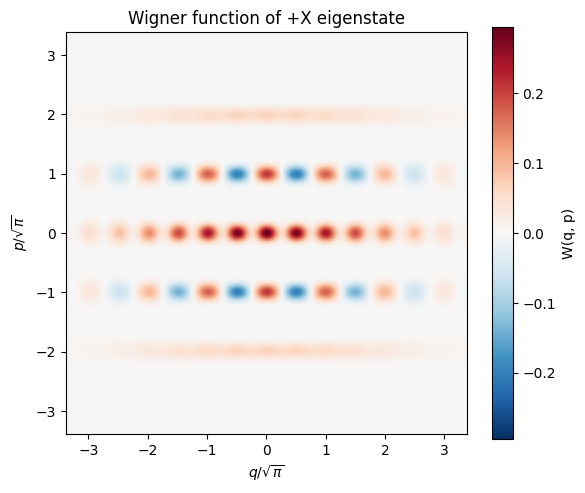

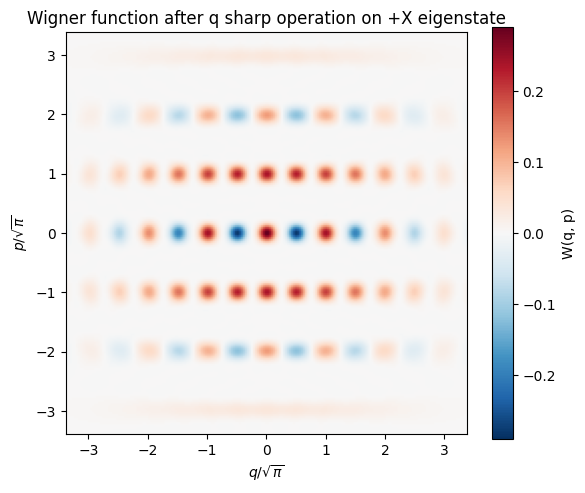

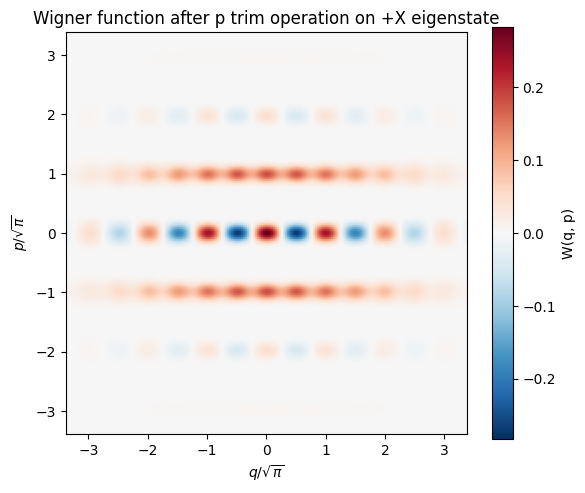

In [17]:
# zxxz are effective gates when doing sharp and trim which equals 1 so all good.
# test this with wigner tomography on X+ state after each sharp and trim round

gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('X', 1, 2) # measure from mixed logical state, get pure state. This is +X eigenstate

gkp_state.plot_wigner(gkp_state.rho_logical_pure, title_str=f'Wigner function of +X eigenstate') # plot
gkp_state.plot_wigner(gkp_state.sharp_trim(gkp_state.rho_logical_pure, 'q', 'sharp',eps_trim=gkp_state.eps_trim_default,delta_fb=gkp_state.delta_fb_default), title_str=f'Wigner function after q sharp operation on +X eigenstate') # plot
gkp_state.plot_wigner(gkp_state.sharp_trim(gkp_state.rho_logical_pure, 'p', 'trim',eps_trim=gkp_state.eps_trim_default,delta_fb=gkp_state.delta_fb_default), title_str=f'Wigner function after p trim operation on +X eigenstate') # plot

# Optimize eps_trim for preserving state

In [45]:
num_sharp_and_trim_cycles_stab = 20 # first stabalize for some cycles
num_sharp_and_trim_cycles_error = 50 # then do sharp and trim cycles to see error in sharp and trim 

delta_fb_array = np.linspace(0.07,0.2,6)

eps_trim_array = np.linspace(0.17,0.37,12)
logical_Z_expectation_value_difference = {}

count = 0
for delta_fb_value in delta_fb_array:
    for eps_trim_value in eps_trim_array:
        rho_mixed = gkp_state.run_stabalization(n_cycles=num_sharp_and_trim_cycles_stab, eps_trim=eps_trim_value, delta_fb=delta_fb_value) # first stabalize for some cycles
        rho_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2, rho=rho_mixed) # get pure +Z state from mixed state after stabalization
        rho_error = gkp_state.run_stabalization(rho = rho_pure, n_cycles=num_sharp_and_trim_cycles_error, eps_trim=eps_trim_value, delta_fb=delta_fb_value) # do sharp and trim cycles to see error

        logical_Z_expectation_value_difference.setdefault(count, []).append(np.abs((rho_pure*gkp_state.Z_logical).tr().real - (rho_error*gkp_state.Z_logical).tr().real)) # store difference in logical Z expectation value
    
    count += 1

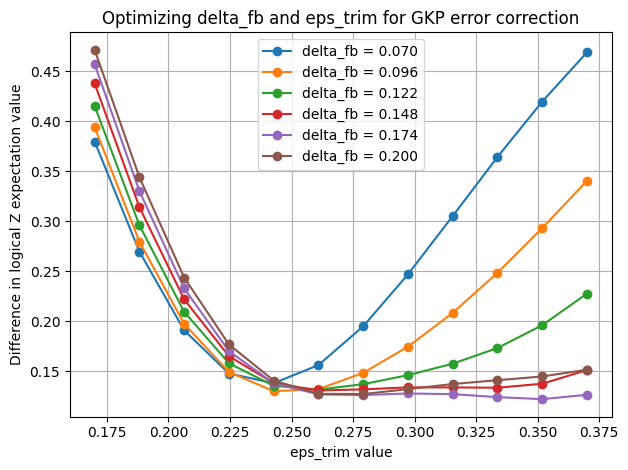

In [48]:
plt.figure()

for i in range(len(delta_fb_array)):
    plt.plot(eps_trim_array, logical_Z_expectation_value_difference[i], marker='o', label=f'delta_fb = {delta_fb_array[i]:.3f}')
plt.xlabel('eps_trim value')
plt.ylabel('Difference in logical Z expectation value')
plt.title('Optimizing delta_fb and eps_trim for GKP error correction')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [49]:
print(eps_trim_array[6])

0.2790909090909091


In [50]:
gkp_state.eps_trim_default = 0.279
gkp_state.delta_fb_default = 0.174

print(gkp_state.eps_trim_default)

gkp_state.rho_logical_mixed = gkp_state.run_stabalization() # perform st stabalization
gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2) # measure from mixed logical state, get pure state. This is +Z eigenstate

states_after_sharp_and_trim = [gkp_state.rho_logical_pure.copy()] # store states after each sharp and trim stabilization cycle
rho = states_after_sharp_and_trim[0]

num_sharp_and_trim_cycles = 1000

for k in range(num_sharp_and_trim_cycles):
    # 2) one full sharp+trim round (q-sharp, q-trim, p-sharp, p-trim)
    rho = gkp_state.GKP_stabalization_sharp_trim_cycle(rho, eps_trim = gkp_state.eps_trim_default, delta_fb = gkp_state.delta_fb_default)
    # 3) store state right after QEC (sharp+trim)
    states_after_sharp_and_trim.append(rho.copy())

0.279


0.12625830447245123


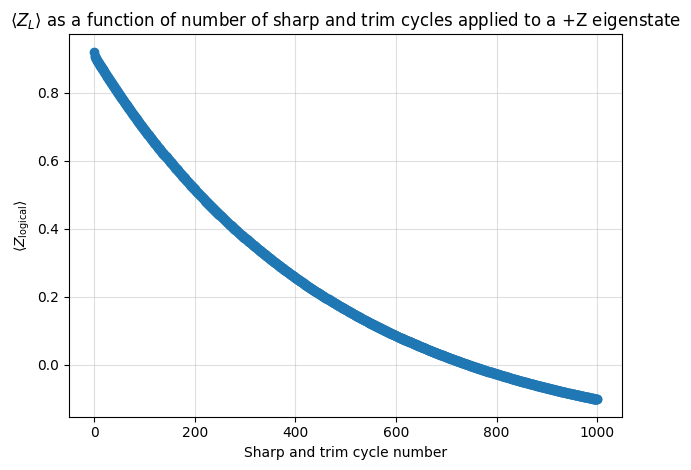

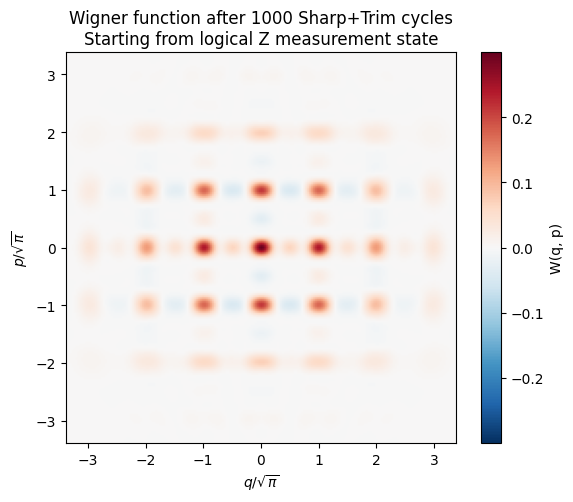

In [60]:
gkp_state.rho_logical_mixed = gkp_state.run_stabalization() # perform st stabalization
gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2) # measure from mixed logical state, get pure state. This is +Z eigenstate
# error_state = gkp_state.run_stabalization(rho = gkp_state.rho_logical_pure, n_cycles=num_sharp_and_trim_cycles_error) # do sharp and trim cycles to see error

# print((gkp_state.rho_logical_pure*gkp_state.Z_logical).tr().real - (error_state*gkp_state.Z_logical).tr().real)

Z_plus_expectation_sharp_and_trim = gkp_state.get_expectation_values(states_after_sharp_and_trim, gkp_state.Z_logical)

plt.figure()

cycle_idx = np.arange(len(Z_plus_expectation_sharp_and_trim))

plt.plot(
    cycle_idx,
    Z_plus_expectation_sharp_and_trim,
    marker='o',
    linestyle='-',
)

print(Z_plus_expectation_sharp_and_trim[0] - Z_plus_expectation_sharp_and_trim[50])

plt.xlabel("Sharp and trim cycle number")
plt.ylabel(r"$\langle Z_{\mathrm{logical}} \rangle$")
plt.title(r"$\langle Z_L \rangle$ as a function of number of sharp and trim cycles applied to a +Z eigenstate")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

gkp_state.plot_wigner(states_after_sharp_and_trim[-1], title_str=f'Wigner function after {num_sharp_and_trim_cycles} Sharp+Trim cycles\nStarting from logical Z measurement state')

In [61]:
# --- Lindblad parameters ---
gkp_state.kappa     = 5e3   # energy decay rate  (set this to whatever you want)
gkp_state.kappa_phi = 1e2      # dephasing rate    (set nonzero if you want D[n])
gkp_state.t_between_QEC = 1e-5         # physical time between sharp+trim cycles. making this smaller does not necessarily help. There is an optimal value given kappa and the delta_fb and eps_trim.
gkp_state.n_QEC_cycles = 100        # number of QEC cycles to simulate

gkp_state.rho_logical_pure = gkp_state.GKP_pauli_measurment('Z', 1, 2) # measure from mixed logical state, get pure state. This is +Z eigenstate

gkp_state.rhos_after_QEC, times = gkp_state.QEC_time_evolution(gkp_state.rho_logical_pure)

In [66]:
gkp_state.rhos_no_QEC, times = gkp_state.no_QEC_time_evolution(gkp_state.rho_logical_pure)

In [67]:
# 0 , 1 qubit lifetime simulation

c_ops = [np.sqrt(gkp_state.kappa) * gkp_state.a , np.sqrt(gkp_state.kappa_phi) * gkp_state.n_op]

result_01 = qt.mesolve(
    0*gkp_state.a.dag()*gkp_state.a,
    qt.fock_dm(N,1),
    times,
    c_ops=c_ops,
    e_ops=[]
)

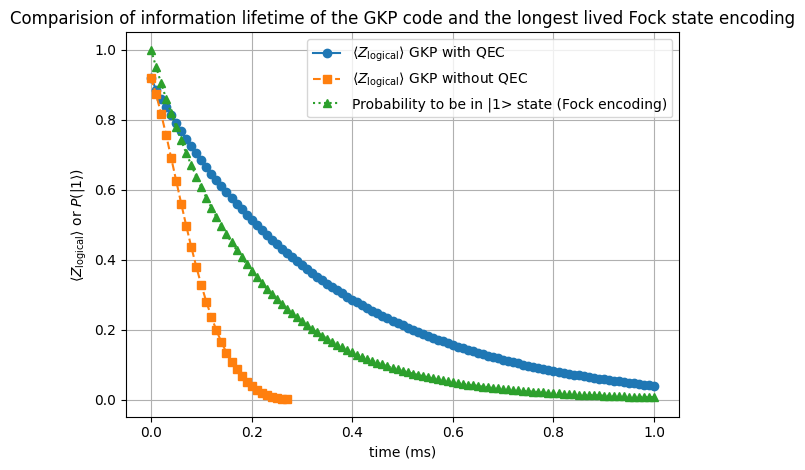

In [68]:
# ----- with QEC -----
Z_plus_expectation_QEC = gkp_state.get_expectation_values(gkp_state.rhos_after_QEC, gkp_state.Z_logical)
# ----- without QEC -----
Z_plus_expectation_noQEC = gkp_state.get_expectation_values(gkp_state.rhos_no_QEC, gkp_state.Z_logical)
# 0 1 qubit lifetime
prob_1 = [result_01.states[i].matrix_element(qt.fock(N,1), qt.fock(N,1)).real for i in range(len(times))]

# convert times to ms
times_ms = times * 1e3

length_probtimes = 28

# ----- plot both -----
plt.figure()
plt.plot(times_ms, Z_plus_expectation_QEC, marker='o', label=r'$\langle Z_{\mathrm{logical}} \rangle$ GKP with QEC')
plt.plot(times_ms[0:length_probtimes], Z_plus_expectation_noQEC[0:length_probtimes], marker='s', linestyle='--', label=r'$\langle Z_{\mathrm{logical}} \rangle$ GKP without QEC')
plt.plot(times_ms, prob_1, marker='^', linestyle=':', label='Probability to be in |1> state (Fock encoding)')

plt.xlabel("time (ms)")
plt.ylabel(r"$\langle Z_{\mathrm{logical}} \rangle$ or $P(|1\rangle)$")
plt.title(r"Comparision of information lifetime of the GKP code and the longest lived Fock state encoding")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

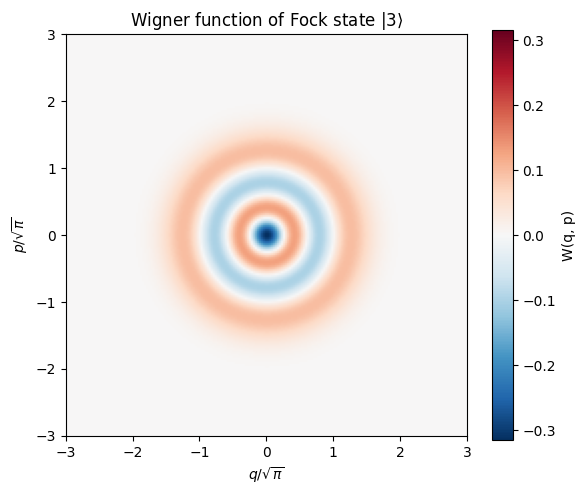

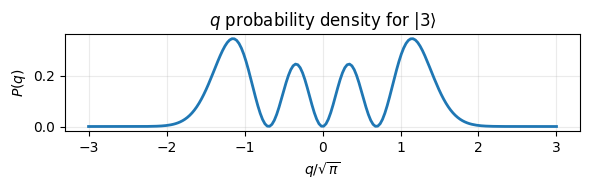

In [69]:
# --- choose the state ---
n_fock = 3
rho = qt.fock_dm(N, n_fock)

# --- Wigner (use GKP-natural window +/- 3*sqrt(pi)) ---
gkp_state.plot_wigner(
    rho,
    title_str=rf"Wigner function of Fock state $|{n_fock}\rangle$",
    # if your plot_wigner supports limits, keep them consistent with the marginal:
    xmax=3*np.sqrt(np.pi),
    npts=200
)

# --- q-marginal (convert axis to q / sqrt(pi), and density to 1/sqrt(pi) units) ---
Pq, q = gkp_state.get_q_marginal(rho, xmax=3*np.sqrt(np.pi), npts=200)

q_tilde = q / np.sqrt(np.pi)            # dimensionless coordinate: q / sqrt(pi)
Pq_tilde = Pq          # density in units of 1/sqrt(pi)

plt.figure(figsize=(6,2))
plt.plot(q_tilde, Pq_tilde, linewidth=2)
plt.xlabel(r"$q/\sqrt{\pi}$")
plt.ylabel(r"$P(q)$")
plt.title(rf"$q$ probability density for $|{n_fock}\rangle$")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
